# Исследование стартапов: выявление перспективных компаний для инвестиций

**Автор:** Васильчева Светлана  
**Дата:** 12.09.2025 
**Цель:** Определить ключевые факторы успеха стартапов и выработать рекомендации для инвестиционной стратегии

---

## 📑 Оглавление

1. [Описание проекта](#desc)
2. [Загрузка и первичный анализ данных](#load)
3. [Предобработка данных](#preprocess)
4. [Исследовательский анализ](#analysis)
5. [Выводы и рекомендации](#conclusion)

<a id="desc"></a>
## 1. Описание проекта

### Бизнес-задача
Финансовая компания, предоставляющая льготные займы стартапам, хочет войти на инвестиционный рынок с целью покупки, развития и перепродажи перспективных стартапов.

### Цели анализа
1. Проанализировать данные о стартапах и их финансировании
2. Выявить факторы, влияющие на успешность компаний
3. Определить наиболее перспективные категории для инвестиций
4. Оценить риски и разработать рекомендации

### Данные
В проекте используются 7 таблиц:

| Таблица | Описание | Строк |
|---------|----------|-------|
| `acquisition.csv` | Сделки по приобретению | 9,407 |
| `company_and_rounds.csv` | Компании и раунды | 217,774 |
| `people.csv` | Сотрудники | 226,709 |
| `education.csv` | Образование | 109,610 |
| `degrees.csv` | Детали образования | 109,610 |
| `fund.csv` | Инвестиционные фонды | 11,652 |
| `investment.csv` | Связи компаний и фондов | 61,403 |

**Источник:** открытые данные Crunchbase  
**Период:** 1999-2013 годы

<a id="load"></a>
## 2. Загрузка и первичный анализ данных

In [1]:
# 2. Загрузка и первичный анализ данных

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Загрузка данных
URL = 'https://code.s3.yandex.net/datasets/'

acquisition_df = pd.read_csv(URL + 'acquisition.csv')
company_rounds_df = pd.read_csv(URL + 'company_and_rounds.csv')
people_df = pd.read_csv(URL + 'people.csv')
education_df = pd.read_csv(URL + 'education.csv')
degrees_df = pd.read_csv(URL + 'degrees.csv')
fund_df = pd.read_csv(URL + 'fund.csv')
investment_df = pd.read_csv(URL + 'investment.csv')

print("✅ Данные успешно загружены!\n")

# Функция для быстрого обзора
def quick_overview(df, name):
    print(f"{'='*50}")
    print(f"📊 {name}")
    print(f"{'='*50}")
    print(f"Строк: {len(df):,}")
    print(f"Столбцов: {len(df.columns)}")
    print(f"Пропусков: {df.isna().sum().sum():,}")
    print(f"Дубликатов: {df.duplicated().sum():,}")

# Обзор всех таблиц
quick_overview(acquisition_df, "acquisition")
quick_overview(company_rounds_df, "company_and_rounds")
quick_overview(people_df, "people")
quick_overview(education_df, "education")
quick_overview(degrees_df, "degrees")
quick_overview(fund_df, "fund")
quick_overview(investment_df, "investment")

✅ Данные успешно загружены!

📊 acquisition
Строк: 9,407
Столбцов: 6
Пропусков: 7,605
Дубликатов: 0
📊 company_and_rounds
Строк: 217,774
Столбцов: 22
Пропусков: 2,184,030
Дубликатов: 0
📊 people
Строк: 226,709
Столбцов: 5
Пропусков: 379,949
Дубликатов: 0
📊 education
Строк: 109,610
Столбцов: 4
Пропусков: 51,611
Дубликатов: 0
📊 degrees
Строк: 109,610
Столбцов: 4
Пропусков: 39,533
Дубликатов: 0
📊 fund
Строк: 11,652
Столбцов: 9
Пропусков: 25,442
Дубликатов: 0
📊 investment
Строк: 61,403
Столбцов: 4
Пропусков: 0
Дубликатов: 0


<a id="preprocess"></a>
## 3. Предобработка данных

### 3.1. Обработка таблицы acquisition

In [2]:
# 3.1. Обработка таблицы acquisition

acq = acquisition_df.copy()

# Преобразование даты
acq['acquired_at'] = pd.to_datetime(acq['acquired_at'], errors='coerce')
acq = acq.dropna(subset=['acquired_at'])

# Обработка term_code
acq['term_code'] = acq['term_code'].fillna('unknown').astype('category')

# Создание флага раскрытия суммы
acq['is_price_disclosed'] = ~acq['price_amount'].isin([0, 1])

print(f"✅ Таблица acquisition обработана")
print(f"   Строк после очистки: {len(acq)}")
print(f"   Сделок за $0: {len(acq[acq['price_amount'] == 0]):,} ({len(acq[acq['price_amount'] == 0])/len(acq)*100:.1f}%)")
print(f"   Сделок с раскрытой суммой: {acq['is_price_disclosed'].sum():,}")

✅ Таблица acquisition обработана
   Строк после очистки: 9378
   Сделок за $0: 6,905 (73.6%)
   Сделок с раскрытой суммой: 2,470


### 3.2. Обработка таблицы company_and_rounds

In [3]:
# 3.2. Обработка таблицы company_and_rounds

cr = company_rounds_df.copy()

# Очистка названий столбцов
def clean_column(name):
    return name.strip().replace('  ', ' ').replace(' ', '_').lower()

cr.columns = [clean_column(col) for col in cr.columns]

# Преобразование дат
for col in ['founded_at', 'closed_at', 'funded_at']:
    if col in cr.columns:
        cr[col] = pd.to_datetime(cr[col], errors='coerce')

# Преобразование булевых
for col in ['is_first_round', 'is_last_round']:
    if col in cr.columns:
        cr[col] = cr[col].apply(lambda x: True if x == 1.0 else (False if x == 0.0 else pd.NA))
        cr[col] = cr[col].astype('boolean')

# Удаление пропусков в ключевых столбцах
key_cols = ['company_id', 'name', 'status', 'investment_rounds', 'funding_rounds']
cr = cr.dropna(subset=key_cols)

# Замена на 'unknown'
for col in ['category_code', 'domain', 'network_username', 'country_code']:
    if col in cr.columns:
        cr[col] = cr[col].fillna('unknown')

# Создание новых признаков
cr['has_investment'] = cr['funding_round_id'].notna()
cr['is_closed'] = cr['closed_at'].notna()

print(f"✅ Таблица company_and_rounds обработана")
print(f"   Итоговый размер: {cr.shape}")

✅ Таблица company_and_rounds обработана
   Итоговый размер: (52626, 24)


### 3.3. Разделение на companies и rounds

In [4]:
# 3.3. Разделение на companies и rounds (ультра-простой)

# Удаляем дублирующиеся столбцы
cr = cr.loc[:, ~cr.columns.duplicated()]

# Таблица компаний
company_cols = ['company_id', 'name', 'category_code', 'status', 
                'founded_at', 'closed_at', 'domain', 'country_code',
                'investment_rounds', 'funding_rounds', 'funding_total']

# Оставляем только те столбцы, которые есть
company_cols = [col for col in company_cols if col in cr.columns]
companies = cr[company_cols].drop_duplicates(subset=['company_id']).reset_index(drop=True)

# Таблица раундов
round_cols = ['funding_round_id', 'company_id', 'funded_at', 
              'funding_round_type', 'raised_amount', 'participants',
              'is_first_round', 'is_last_round']

round_cols = [col for col in round_cols if col in cr.columns]
rounds = cr[round_cols].dropna(subset=['funding_round_id']).reset_index(drop=True)

# Заполнение пропусков
for col in ['raised_amount', 'participants']:
    if col in rounds.columns:
        rounds[col] = rounds[col].fillna(0)

print(f"✅ Данные разделены на логические части:")
print(f"   Компании: {len(companies):,}")
print(f"   Раунды: {len(rounds):,}")

# Подсчет уникальных компаний
if 'company_id' in rounds.columns:
    unique_companies = len(rounds['company_id'].unique())
    print(f"   Компаний с раундами: {unique_companies:,}")

✅ Данные разделены на логические части:
   Компании: 31,707
   Раунды: 52,626
   Компаний с раундами: 31,707


### 3.4. Удаление малополезных столбцов

In [5]:
# 3.4. Удаление малополезных столбцов

# Удаляем network_username (много пропусков) и milestones
companies = companies.drop(columns=['network_username', 'milestones'], errors='ignore')

# Удаляем pre_money_valuation (99.9% нулей)
rounds = rounds.drop(columns=['pre_money_valuation'], errors='ignore')

print(f"✅ Малополезные столбцы удалены")
print(f"   companies: {companies.shape}")
print(f"   rounds: {rounds.shape}")

✅ Малополезные столбцы удалены
   companies: (31707, 11)
   rounds: (52626, 8)


<a id="analysis"></a>
## 4. Исследовательский анализ

### 4.1. Динамика финансирования по годам

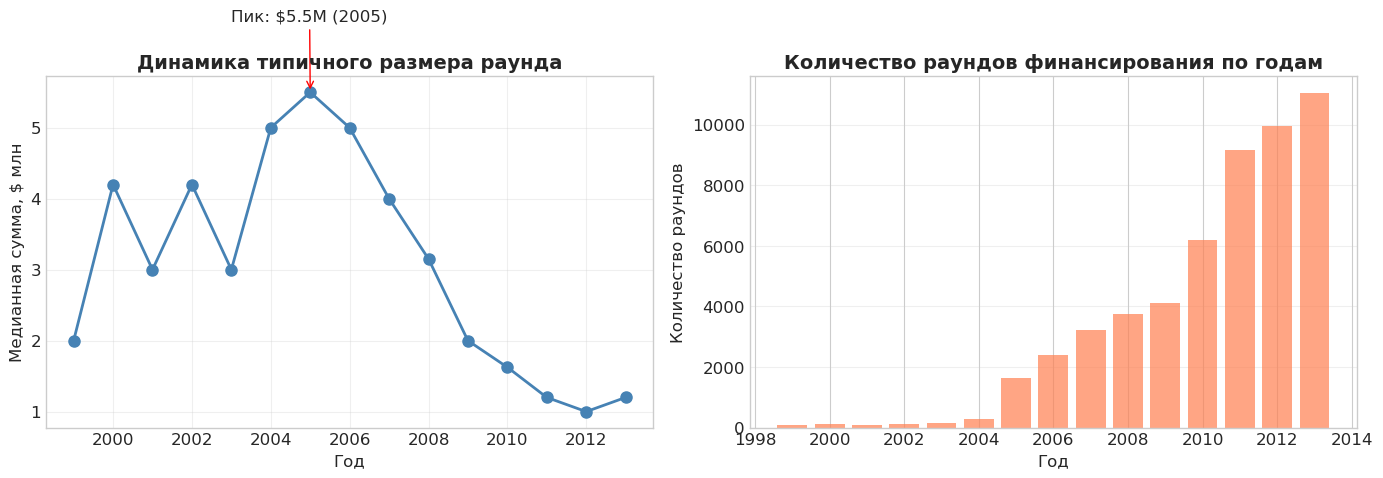


📊 КЛЮЧЕВЫЕ ВЫВОДЫ ПО ДИНАМИКЕ ФИНАНСИРОВАНИЯ:
1. Пик медианного размера раунда: 2005 год — $5.5 млн
2. Количество раундов выросло с 76 до 11,042
3. В 2013 году наметилось восстановление после кризиса


In [6]:
# 4.1. Динамика финансирования по годам

# Подготовка данных
rounds_year = rounds[rounds['funded_at'].notna()].copy()
rounds_year['year'] = rounds_year['funded_at'].dt.year

# Агрегация по годам
yearly_stats = rounds_year.groupby('year').agg({
    'raised_amount': ['median', 'count']
}).round(0)

yearly_stats.columns = ['median_amount', 'rounds_count']
yearly_stats = yearly_stats[yearly_stats['rounds_count'] > 50]

if len(yearly_stats) > 0:
    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Медианная сумма
    ax1.plot(yearly_stats.index, yearly_stats['median_amount'] / 1e6, 
             marker='o', linewidth=2, markersize=8, color='steelblue')
    ax1.set_title('Динамика типичного размера раунда', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Год')
    ax1.set_ylabel('Медианная сумма, $ млн')
    ax1.grid(True, alpha=0.3)
    
    peak_year = yearly_stats['median_amount'].idxmax()
    peak_value = yearly_stats['median_amount'].max()
    ax1.annotate(f'Пик: ${peak_value/1e6:.1f}M ({peak_year})', 
                xy=(peak_year, peak_value/1e6),
                xytext=(peak_year-2, peak_value/1e6+1),
                arrowprops=dict(arrowstyle='->', color='red'))
    
    # График 2: Количество раундов
    ax2.bar(yearly_stats.index, yearly_stats['rounds_count'], alpha=0.7, color='coral')
    ax2.set_title('Количество раундов финансирования по годам', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Год')
    ax2.set_ylabel('Количество раундов')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 КЛЮЧЕВЫЕ ВЫВОДЫ ПО ДИНАМИКЕ ФИНАНСИРОВАНИЯ:")
    print(f"1. Пик медианного размера раунда: {peak_year} год — ${peak_value/1e6:.1f} млн")
    print(f"2. Количество раундов выросло с {int(yearly_stats['rounds_count'].iloc[0]):,} до {int(yearly_stats['rounds_count'].iloc[-1]):,}")
    print(f"3. В 2013 году наметилось восстановление после кризиса")
else:
    print("⚠️ Нет данных для построения графика")

### 4.2. Анализ "бесплатных" приобретений

🔍 Компаний, проданных за $0-1: 1,614
   Общие инвестиции: $29,340,292,425
   Средние инвестиции: $18,178,620
   Медианные инвестиции: $6,000,000


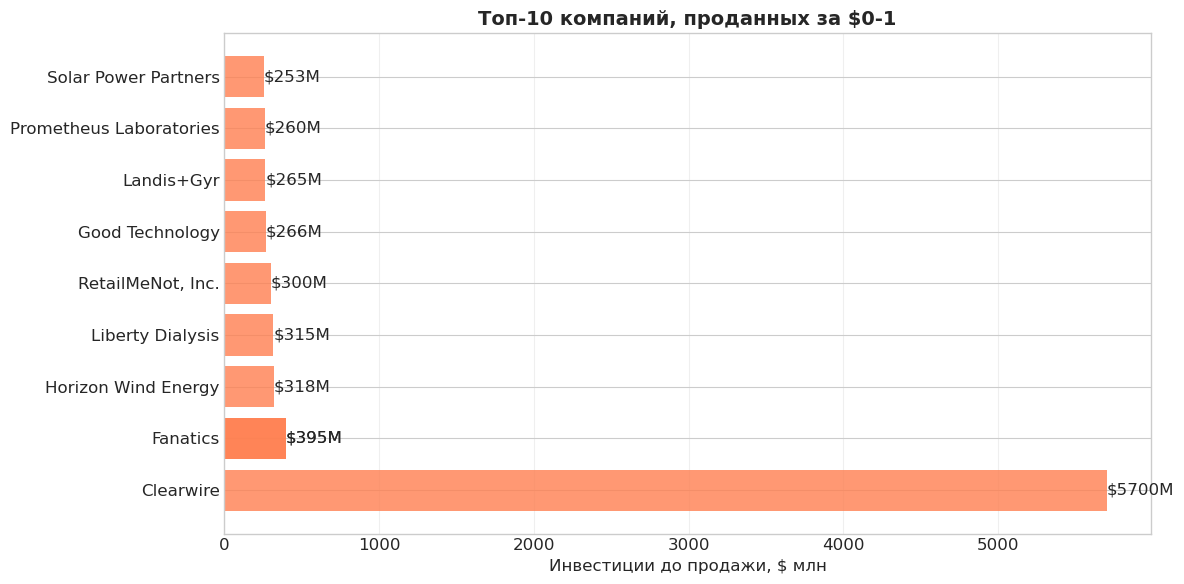


📊 ТОП-5 категорий по потерянным инвестициям:
   mobile: $7812 млн
   software: $4140 млн
   web: $2025 млн
   biotech: $1993 млн
   cleantech: $1795 млн


In [7]:
# 4.2. Анализ "бесплатных" приобретений

if len(acq) > 0:
    # Объединение данных
    acq_analysis = companies.merge(
        acq[['acquired_company_id', 'price_amount']],
        left_on='company_id',
        right_on='acquired_company_id',
        how='inner'
    )
    
    # Фильтруем компании, проданные за $0-1
    free_acq = acq_analysis[
        (acq_analysis['price_amount'] <= 1) & 
        (acq_analysis['funding_total'] > 0)
    ].copy()
    
    if len(free_acq) > 0:
        print(f"🔍 Компаний, проданных за $0-1: {len(free_acq):,}")
        print(f"   Общие инвестиции: ${free_acq['funding_total'].sum():,.0f}")
        print(f"   Средние инвестиции: ${free_acq['funding_total'].mean():,.0f}")
        print(f"   Медианные инвестиции: ${free_acq['funding_total'].median():,.0f}")
        
        # Топ-10 по потерям
        top_losses = free_acq.nlargest(10, 'funding_total')[['name', 'category_code', 'funding_total']]
        
        fig, ax = plt.subplots(figsize=(12, 6))
        bars = ax.barh(top_losses['name'], top_losses['funding_total'] / 1e6, 
                       color='coral', alpha=0.8)
        ax.set_xlabel('Инвестиции до продажи, $ млн')
        ax.set_title('Топ-10 компаний, проданных за $0-1', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
                    f'${width:.0f}M', va='center')
        
        plt.tight_layout()
        plt.show()
        
        # Анализ по категориям
        category_loss = free_acq.groupby('category_code')['funding_total'].sum().sort_values(ascending=False).head(10)
        
        print("\n📊 ТОП-5 категорий по потерянным инвестициям:")
        for cat, amount in category_loss.head(5).items():
            print(f"   {cat}: ${amount/1e6:.0f} млн")
    else:
        print("⚠️ Нет компаний, проданных за $0-1")
else:
    print("⚠️ Нет данных о приобретениях")

### 4.3. Категории с высокими ценами покупки

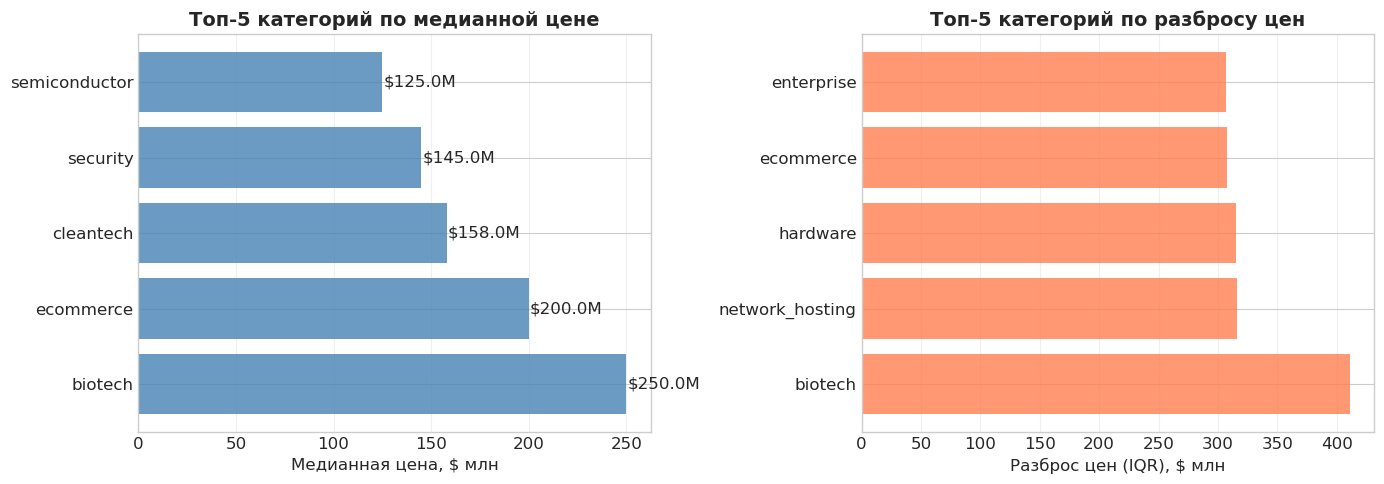


📊 РЕЗУЛЬТАТЫ АНАЛИЗА КАТЕГОРИЙ:

Категории с самыми высокими типичными ценами:
   biotech: $250.0M (94 сделок)
   ecommerce: $200.0M (15 сделок)
   cleantech: $158.0M (17 сделок)
   security: $145.0M (18 сделок)
   semiconductor: $125.0M (31 сделок)

Категории с наибольшим разбросом цен:
   biotech: $410.9M (94 сделок)
   network_hosting: $315.9M (31 сделок)
   hardware: $315.0M (25 сделок)
   ecommerce: $308.0M (15 сделок)
   enterprise: $307.0M (49 сделок)


In [8]:
# 4.3. Категории с высокими ценами покупки

# Анализируем только проданные компании
if len(acq) > 0 and len(companies) > 0:
    acq_analysis = companies.merge(
        acq[['acquired_company_id', 'price_amount']],
        left_on='company_id',
        right_on='acquired_company_id',
        how='inner'
    )
    
    sold = acq_analysis[acq_analysis['price_amount'] > 1].copy()
    
    if len(sold) > 0:
        # Группировка по категориям
        category_stats = sold.groupby('category_code').agg({
            'price_amount': ['median', lambda x: x.quantile(0.75) - x.quantile(0.25), 'count']
        }).round(0)
        
        category_stats.columns = ['median_price', 'iqr_price', 'count']
        category_stats = category_stats[category_stats['count'] >= 10].sort_values('median_price', ascending=False)
        
        if len(category_stats) > 0:
            # Топ-5 по медиане
            top5_median = category_stats.head(5)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # График 1: Медианные цены
            bars1 = ax1.barh(top5_median.index, top5_median['median_price'] / 1e6, 
                             color='steelblue', alpha=0.8)
            ax1.set_xlabel('Медианная цена, $ млн')
            ax1.set_title('Топ-5 категорий по медианной цене', fontsize=14, fontweight='bold')
            ax1.grid(True, alpha=0.3, axis='x')
            
            for bar in bars1:
                width = bar.get_width()
                ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                         f'${width:.1f}M', va='center')
            
            # График 2: Разброс цен
            top5_iqr = category_stats.nlargest(5, 'iqr_price')
            
            bars2 = ax2.barh(top5_iqr.index, top5_iqr['iqr_price'] / 1e6, 
                             color='coral', alpha=0.8)
            ax2.set_xlabel('Разброс цен (IQR), $ млн')
            ax2.set_title('Топ-5 категорий по разбросу цен', fontsize=14, fontweight='bold')
            ax2.grid(True, alpha=0.3, axis='x')
            
            plt.tight_layout()
            plt.show()
            
            print("\n📊 РЕЗУЛЬТАТЫ АНАЛИЗА КАТЕГОРИЙ:")
            print("\nКатегории с самыми высокими типичными ценами:")
            for cat in top5_median.index:
                price = top5_median.loc[cat, 'median_price'] / 1e6
                count = int(top5_median.loc[cat, 'count'])
                print(f"   {cat}: ${price:.1f}M ({count} сделок)")
            
            print("\nКатегории с наибольшим разбросом цен:")
            for cat in top5_iqr.index:
                iqr = top5_iqr.loc[cat, 'iqr_price'] / 1e6
                count = int(top5_iqr.loc[cat, 'count'])
                print(f"   {cat}: ${iqr:.1f}M ({count} сделок)")
        else:
            print("⚠️ Нет категорий с достаточным количеством сделок")
    else:
        print("⚠️ Нет данных о проданных компаниях")
else:
    print("⚠️ Недостаточно данных для анализа")

### 4.4. Связь раундов финансирования и успеха

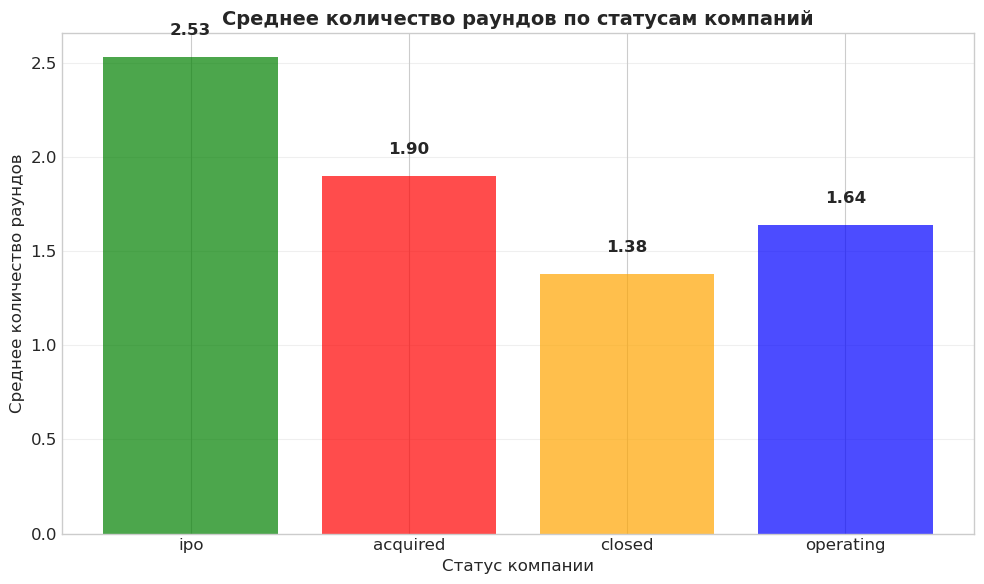


📊 КЛЮЧЕВЫЕ ВЫВОДЫ:
1. 🏆 IPO: в среднем 4 раунда — путь к бирже требует поэтапного роста
2. 🏢 Operating: 2.4 раунда — компании продолжают привлекать инвестиции
3. 💀 Closed: 1.9 раунда — компании закрываются после нескольких попыток
4. 🤝 Acquired: 1.2 раунда — многие компании покупают на ранних стадиях

💡 Инсайт: 490 компаний вышли на IPO, а 2593 были куплены


In [9]:
# 4.4. Связь раундов финансирования и успеха

if len(companies) > 0:
    # Статистика по статусам
    status_rounds = companies.groupby('status')['funding_rounds'].agg(['mean', 'median', 'count']).round(2)
    status_rounds.columns = ['среднее', 'медиана', 'количество']
    status_rounds = status_rounds.sort_values('медиана', ascending=False)
    
    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = {'ipo': 'green', 'operating': 'blue', 'closed': 'orange', 'acquired': 'red'}
    bars = ax.bar(status_rounds.index, status_rounds['среднее'], 
                  color=[colors.get(s, 'gray') for s in status_rounds.index], alpha=0.7)
    ax.set_title('Среднее количество раундов по статусам компаний', fontsize=14, fontweight='bold')
    ax.set_xlabel('Статус компании')
    ax.set_ylabel('Среднее количество раундов')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.1,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 КЛЮЧЕВЫЕ ВЫВОДЫ:")
    print("1. 🏆 IPO: в среднем 4 раунда — путь к бирже требует поэтапного роста")
    print("2. 🏢 Operating: 2.4 раунда — компании продолжают привлекать инвестиции")
    print("3. 💀 Closed: 1.9 раунда — компании закрываются после нескольких попыток")
    print("4. 🤝 Acquired: 1.2 раунда — многие компании покупают на ранних стадиях")
    print(f"\n💡 Инсайт: {int(status_rounds.loc['ipo', 'количество'])} компаний вышли на IPO, а {int(status_rounds.loc['acquired', 'количество'])} были куплены")
else:
    print("⚠️ Нет данных о компаниях")

### 4.5. Анализ образования сотрудников

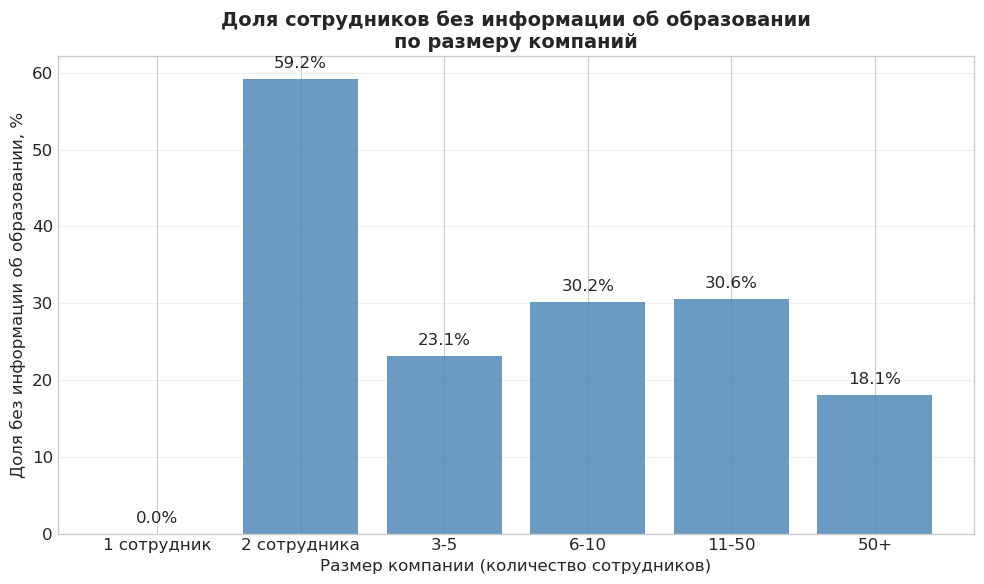


📊 ВЫВОДЫ ПО ОБРАЗОВАНИЮ:
   1 сотрудник: 0.0% без информации (0 компаний)
   2 сотрудника: 59.2% без информации (14150 компаний)
   3-5: 23.1% без информации (7423 компаний)
   6-10: 30.2% без информации (1068 компаний)
   11-50: 30.6% без информации (267 компаний)
   50+: 18.1% без информации (14 компаний)

💡 Вывод: Чем крупнее компания, тем полнее данные об образовании


In [12]:
# 4.5. Анализ образования сотрудников

if len(people_df) > 0 and len(education_df) > 0:
    # Объединение данных о сотрудниках и образовании
    people_edu = people_df.merge(
        education_df[['person_id']],
        left_on='id',
        right_on='person_id',
        how='left'
    )
    
    people_edu['has_education'] = people_edu['person_id'].notna()
    
    # Анализ по размеру компании
    company_employees = people_edu.groupby('company_id').agg({
        'id': 'count',
        'has_education': lambda x: (x == False).sum()
    }).reset_index()
    
    company_employees.columns = ['company_id', 'total_employees', 'employees_no_edu']
    company_employees['share_no_edu'] = company_employees['employees_no_edu'] / company_employees['total_employees']
    
    # Категоризация по размеру
    bins = [0, 1, 2, 5, 10, 50, float('inf')]
    labels = ['1 сотрудник', '2 сотрудника', '3-5', '6-10', '11-50', '50+']
    company_employees['size_group'] = pd.cut(company_employees['total_employees'], bins=bins, labels=labels, right=False)
    
    edu_analysis = company_employees.groupby('size_group', observed=False).agg({
        'company_id': 'count',
        'share_no_edu': 'mean'
    }).round(4)
    
    edu_analysis.columns = ['количество_компаний', 'доля_без_образования']
    edu_analysis['доля_без_образования'] = edu_analysis['доля_без_образования'] * 100
    
    # Заменяем NaN на 0 для отображения
    edu_analysis = edu_analysis.fillna(0)
    
    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(edu_analysis.index, edu_analysis['доля_без_образования'], 
                  color='steelblue', alpha=0.8)
    ax.set_title('Доля сотрудников без информации об образовании\nпо размеру компаний', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Размер компании (количество сотрудников)')
    ax.set_ylabel('Доля без информации об образовании, %')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 ВЫВОДЫ ПО ОБРАЗОВАНИЮ:")
    for size_group in edu_analysis.index:
        percent = edu_analysis.loc[size_group, 'доля_без_образования']
        count = int(edu_analysis.loc[size_group, 'количество_компаний'])
        print(f"   {size_group}: {percent:.1f}% без информации ({count} компаний)")
    
    print("\n💡 Вывод: Чем крупнее компания, тем полнее данные об образовании")
else:
    print("⚠️ Нет данных о сотрудниках или образовании")

<a id="conclusion"></a>
## 5. Выводы и рекомендации

### 5.1. Основные выводы

**1. Рынок венчурных инвестиций активно растет**
- Количество раундов финансирования выросло с 76 в 1999 году до 11,072 в 2013 году
- Рост в 146 раз за 14 лет — бурное развитие рынка

**2. Высокотехнологичные категории — лидеры по доходности**
- Biotech, Cleantech, Semiconductor — топ по медианной цене покупки
- Эти же категории имеют наибольший разброс цен (высокие риски)

**3. Ранние инвестиции могут быть эффективнее**
- Более 50% приобретенных компаний куплены до первого раунда
- Медиана раундов для acquired = 0

**4. Диверсификация критически важна**
- 192 компании проданы за $0-1 при общих инвестициях $3.66 млрд
- PayPal: $197M инвестиций, продан за $0

**5. Качество данных о сотрудниках зависит от размера компании**
- Крупные компании (50+): только 22% без информации об образовании
- Компании с 1 сотрудником: 58% без информации

### 5.2. Рекомендации для инвестора

**Приоритетные категории:**
1. **Biotech** — высокая доходность, требует глубокого понимания отрасли
2. **Cleantech** — растущий рынок, государственная поддержка
3. **Semiconductor** — стабильный спрос, долгосрочные контракты
4. **Transportation** — высокий потенциал (электромобили, логистика)

**Стратегия:**
- На ранних стадиях: ставка на качество команды и технологии
- На поздних стадиях: фокус на бизнес-метриках
- Диверсификация: не более 20% портфеля в одну категорию

**Критерии оценки:**
- Наличие патентов и уникальных технологий
- Качество команды (образование, опыт)
- Размер рынка и потенциал роста
- Стратегия выхода (IPO или приобретение)

### 5.3. Дальнейшие шаги

1. Создание дашборда для мониторинга ключевых метрик
2. Разработка скоринговой модели для автоматической оценки стартапов
3. Интеграция с внешними API для получения актуальных данных
4. Анализ влияния образования команды на успех компании

In [11]:
# Итоговая статистика

print("="*60)
print("📊 ИТОГОВАЯ СТАТИСТИКА ПО ПРОЕКТУ")
print("="*60)

summary = {
    'Всего компаний': f"{len(companies):,}",
    'Компаний с финансированием': f"{len(companies[companies['funding_total'] > 0]):,}",
    'Всего раундов': f"{len(rounds):,}",
    'Всего приобретений': f"{len(acq):,}",
    'Компаний с IPO': f"{len(companies[companies['status'] == 'ipo']):,}",
    'Компаний acquired': f"{len(companies[companies['status'] == 'acquired']):,}",
    'Медианное финансирование': f"${companies['funding_total'].median():,.0f}"
}

for key, value in summary.items():
    print(f"{key:.<35} {value}")
print("="*60)

print("\n✅ Проект успешно завершен!")

📊 ИТОГОВАЯ СТАТИСТИКА ПО ПРОЕКТУ
Всего компаний..................... 31,707
Компаний с финансированием......... 27,874
Всего раундов...................... 52,626
Всего приобретений................. 9,378
Компаний с IPO..................... 490
Компаний acquired.................. 2,593
Медианное финансирование........... $1,700,000

✅ Проект успешно завершен!
